## Assignment 3

Now consider subcritical and supercritical flow over a h0=4 cm high (and lambda=40 cm long) mound in the tilting flume in the DTU Mechanical Engineering Hydraulics Laboratory (building 114):
A video for the subcritical flow case can be found here. (Note that all linked videos here are intentionally
short, and intended to be viewed in a loop – this can be turned out by right clicking on them.) In this case
the water depth upstream of the mound was measured to be D1=11 cm and at the mound D2=6.3 cm

In [52]:
import numpy as np
import sympy as sp
from scipy.optimize import fsolve
import matplotlib.pyplot as plt
from IPython.display import display, Math

In [53]:
# --------------------------
# Determining type of flow
# --------------------------
def determine_flow_type(velocity, depth):
    Froude_number = velocity / np.sqrt(g * depth)

    if Froude_number < 1:
        flow_type = "Subcritical"
    else:
        flow_type = "Supercritical"

    return flow_type, Froude_number

### Question 1
Solve (3.47), (3.51), and (3.57) for c1, c2, and b1. Check the analytic result for b1/h0 versus (3.58)! Hints:
In Mathematica, you may find the ExpToTrig, TrigReduce, and Simplify functions useful. In
Maple, you may similarly find the convert(expr,trig) and simplify functions useful

In [54]:
# Define symbolic variables
c1, c2, b1, h0, V, g, k, D, Fr, kD = sp.symbols('c1 c2 b1 h0 V g k D Fr kD')

# Define equations
eq1 = c1 - c2 - (h0 * V)                                                    # Eq 3.47
eq2 = c1 * sp.exp(k * D) - c2 * sp.exp(-k * D) - (V * b1)                   # Eq 3.51
eq3 = c1 * sp.exp(k * D) + c2 * sp.exp(-k * D) - (g * b1 / (V * k))         # Eq 3.57

# Solve 3 equations for 3 unknowns
S = sp.solve([eq1, eq2, eq3], (c1, c2, b1), dict=True)[0]

c1_sol = sp.simplify(S[c1])
c2_sol = sp.simplify(S[c2])
b1_sol = sp.simplify(S[b1])

# Change exponential terms to sinh/cosh
c1_sol = c1_sol.rewrite(sp.sinh)
c2_sol = c2_sol.rewrite(sp.sinh)
b1_sol = b1_sol.rewrite(sp.sinh)

# Define Froude number
eq4 = sp.Eq(Fr, V / sp.sqrt(g * D))
V_sol = sp.solve(eq4, V)[0]

# b1/h0
b1h0 = sp.simplify(b1_sol / h0)
b1h0 = b1h0.rewrite(sp.sinh)

# Check against eq 3.58
eq5 = (sp.cosh(k * D) - sp.sinh(k * D) / (k * D * Fr**2))**(-1)
Q1_check = sp.simplify(b1h0 - eq5)   # should simplify to 0

print("Check Q1 (should be 0):", Q1_check)

latex_str = sp.latex(eq5)
display(Math(latex_str))

Check Q1 (should be 0): 2*V**2*k*exp(D*k)/(V**2*k*exp(2*D*k) + V**2*k - g*exp(2*D*k) + g) - 1/(cosh(D*k) - sinh(D*k)/(D*Fr**2*k))


<IPython.core.display.Math object>

### Solving on numbers

In [55]:
# --------------------------
# Constants and known values
# --------------------------
h0 = 0.04               # Mound height (m)
lam = 0.4               # Mound width (m)
L = 2 * lam             # bottom wavelength (m)
k = 2 * np.pi / L       # wavenumber (1/m)
b = 0.1                 # Amplitude of the bottom undulation [m]
D1_sub = 0.11           # Upstream water depth, subcritical case (m)
D2_sub = 0.063          # Downstream water depth, subcritical case (m)
D1_sup = 0.065        # Upstream water depth, supercritical case (m)
D2_sup = 0.067         # Downstream water depth, supercritical case (m)
g = 9.81                # Gravitational acceleration [m/s^2]
viscosity = 1.003e-6    # Kinematic viscosity [m^2/s]

### Question 2
Consider first the subcritical flow conditions: Solve the Bernoulli equation and continuity equation for
the unknown mean velocities at the two measurement positions. What are the Froude numbers and
are they indeed subcritical? Based on the full potential flow solution for flow over a wavy bed with
equivalent amplitude h0, plot the theoretical bottom and surface elevation. (HINT: the wavenumber
can be calculated as k=2*pi/L, with the bottom wavelength estimated as L=2*lambda i.e. with the mound
representing only the positive half-wavelength). Compare the computed value for b1/h0 with that
based on shallow water theory. Finally, compare the theoretical flow depth (from the full potential
flow solution) beneath the mound crest with the measured value reported above.
Videos for the supercritical flow case can be found here (zoomed out) and here (zoomed in). In this case
the water depth upstream of the mound was measured to be D1=6.5 cm and at the mound D2=6.7 cm


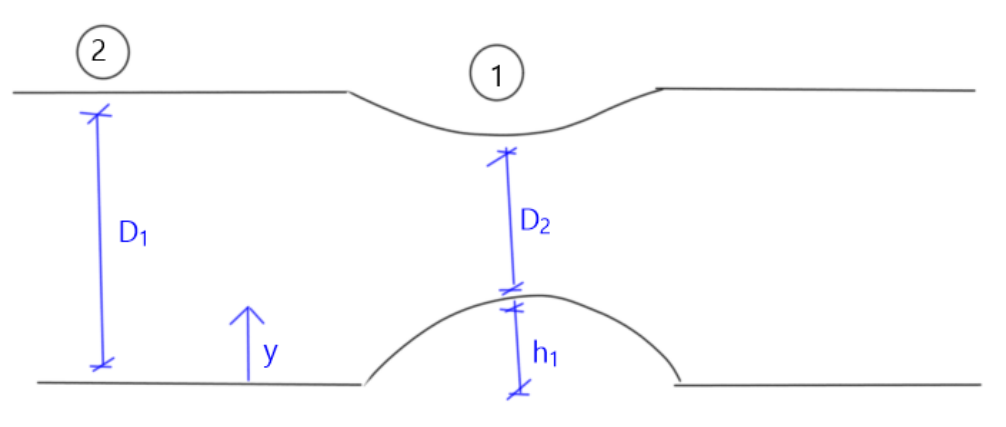

In [56]:
# ---------------------------------------------------------
# Prepare the functions for calulatins eta and b1
# ---------------------------------------------------------

def amplitude_of_first_order_perturbation(h0, D, Fr):
    """Calculate b1"""
    return h0 / (np.cosh(k*D) - np.sinh(k*D)/(k*D*Fr**2))

def free_surface_elevation(h0, b1, h):
    """Calculate eta"""
    return b1/h0 * h

def bottom_elevation(k,x):
    """Calculate h"""
    return h0 * np.sin(k * x)


In [57]:
x = np.arange(0, 2*L+0.01, 0.01)    # x-coordinates (m)
h = bottom_elevation(k,x)

# ---------------------------------------------------------
# System of equations - Bernoulli and continuity equations
# ---------------------------------------------------------
def equations(unknowns, D_1, D_2):
    V1, V2 = unknowns

    bernoulli = D_1 + V1**2 / (2*g) - ((D_2 + h0) + V2**2 / (2*g))
    continuity = V1*D_1 - V2*D_2

    return [bernoulli, continuity]

In [58]:
# -----------------------------------------
# Solve the system for case 1 (subcritical)
# -----------------------------------------
initial_guess = [0.01, 0.1]  # [V_1, V_2]
solution = fsolve(equations, initial_guess, args=(D1_sub, D2_sub))
V_1_sub, V_2_sub = solution

In [59]:
# --------------------------
# Output results
# --------------------------
print(f"Velocity V_1: {V_1_sub:.6f} m/s")
print(f"Velocity V_2: {V_2_sub:.6f} m/s")

flow_type_1_sub, Fr_1_sub = determine_flow_type(V_1_sub, D1_sub)
flow_type_2_sub, Fr_2_sub = determine_flow_type(V_2_sub, D2_sub)

b1_sub = amplitude_of_first_order_perturbation(h0, D1_sub, Fr_1_sub)
eta_sub = free_surface_elevation(h0, b1_sub, h)

print(f"Flow type at section 1: {flow_type_1_sub} (Fr = {Fr_1_sub:.3f})")
print(f"Flow type at section 2: {flow_type_2_sub} (Fr = {Fr_2_sub:.3f})")

Velocity V_1: 0.258921 m/s
Velocity V_2: 0.452084 m/s
Flow type at section 1: Subcritical (Fr = 0.249)
Flow type at section 2: Subcritical (Fr = 0.575)


In [60]:
# --------------------------
# Checks
# --------------------------
check1_sub = b1_sub/h0 - (Fr_1_sub**2/(Fr_1_sub**2 - 1))
check2_sub = (D1_sub + b1_sub - h0) - D2_sub

print("Subcritical checks:", check1_sub, check2_sub)

Subcritical checks: 0.0066385441407521215 0.0046158953474641495


### Question 3
Repeat Part 2 for the supercritical flow condition

In [61]:
# -----------------------------------------
# Solve the system for case 1 (supercritical)
# -----------------------------------------
initial_guess = [0.01, 0.01]  # [V_1, V_2]
solution = fsolve(equations, initial_guess, args=(D1_sup, D2_sup))
V_1_sup, V_2_sup = solution

In [62]:
# --------------------------
# Output results
# --------------------------
print(f"Velocity V_1: {V_1_sup:.6f} m/s")
print(f"Velocity V_2: {V_2_sup:.6f} m/s")

flow_type_1_sup, Fr_1_sup = determine_flow_type(V_1_sup, D1_sup)
flow_type_2_sup, Fr_2_sup = determine_flow_type(V_2_sup, D2_sup)

b1_sup = amplitude_of_first_order_perturbation(h0, D1_sup, Fr_1_sup)
eta_sup = free_surface_elevation(h0, b1_sup, h)

print(f"Flow type at section 1: {flow_type_1_sup} (Fr = {Fr_1_sup:.3f})")
print(f"Flow type at section 2: {flow_type_2_sup} (Fr = {Fr_2_sup:.3f})")

Velocity V_1: 3.743234 m/s
Velocity V_2: 3.631496 m/s
Flow type at section 1: Supercritical (Fr = 4.688)
Flow type at section 2: Supercritical (Fr = 4.479)


In [63]:
# --------------------------
# Checks
# --------------------------
check1_sup = b1_sup/h0 - (Fr_1_sup**2/(Fr_1_sup**2 - 1))
check2_sup = (D1_sup + b1_sup - h0) - D2_sup

print("Subcritical checks:", check1_sub, check2_sub)

Subcritical checks: 0.0066385441407521215 0.0046158953474641495


<>:6: SyntaxWarning: invalid escape sequence '\e'
<>:7: SyntaxWarning: invalid escape sequence '\e'
<>:6: SyntaxWarning: invalid escape sequence '\e'
<>:7: SyntaxWarning: invalid escape sequence '\e'
C:\Users\natal\AppData\Local\Temp\ipykernel_27792\163455391.py:6: SyntaxWarning: invalid escape sequence '\e'
  plt.plot(x, eta_sub + D1_sub, label='$\eta_{subcritical}+D_{subcritical}$')
C:\Users\natal\AppData\Local\Temp\ipykernel_27792\163455391.py:7: SyntaxWarning: invalid escape sequence '\e'
  plt.plot(x, eta_sup + D2_sup, label='$\eta_{supercritical}+D_{supercritical}$')


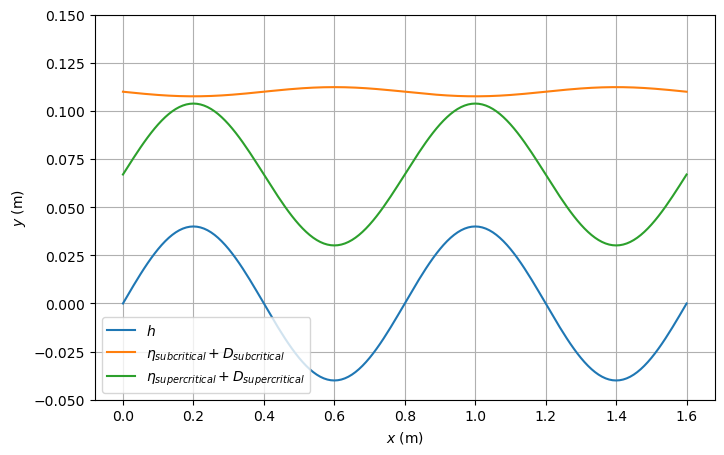

In [64]:
# ===========================================
# Plot results
# ===========================================
plt.figure(figsize=(8,5))
plt.plot(x, h, label='$h$')
plt.plot(x, eta_sub + D1_sub, label='$\eta_{subcritical}+D_{subcritical}$')
plt.plot(x, eta_sup + D2_sup, label='$\eta_{supercritical}+D_{supercritical}$')
plt.xlabel('$x$ (m)')
plt.ylabel('$y$ (m)')
plt.ylim([-0.05, 0.15])
plt.legend()
plt.grid(True, which='both')
plt.show()